In [1]:
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
area = gpd.read_file("../data/main_island/area.shp")

In [3]:
gnss = np.load("../data/GNSS_XYU.pkl", allow_pickle=True)

In [4]:
gnss

station                       GS87                       CKSV           \
coordinate                      dX       dY       dU       dX       dY   
1994-01-01 11:59:00+00:00      NaN      NaN      NaN      NaN      NaN   
1994-01-02 11:59:00+00:00      NaN      NaN      NaN      NaN      NaN   
1994-01-03 11:59:00+00:00      NaN      NaN      NaN      NaN      NaN   
1994-01-04 11:59:00+00:00      NaN      NaN      NaN      NaN      NaN   
1994-01-05 11:59:00+00:00      NaN      NaN      NaN      NaN      NaN   
...                            ...      ...      ...      ...      ...   
2023-12-27 11:59:00+00:00  0.26894 -0.09425 -0.00008  0.16532  0.16945   
2023-12-28 11:59:00+00:00  0.26846 -0.09172  0.00395  0.16787  0.16597   
2023-12-29 11:59:00+00:00  0.27139 -0.09324  0.01083  0.16831  0.16616   
2023-12-30 11:59:00+00:00  0.26879 -0.09236 -0.00108  0.16525  0.16509   
2023-12-31 11:59:00+00:00  0.27199 -0.09264 -0.00480  0.17034  0.16652   

station                            FCU1             HUWE  ... KZON     VR02  \
coordinate                      dU   dX  dY  dU       dX  ...   dU       dX   
1994-01-01 11:59:00+00:00      NaN  NaN NaN NaN      NaN  ...  NaN      NaN   
1994-01-02 11:59:00+00:00      NaN  NaN NaN NaN      NaN  ...  NaN      NaN   
1994-01-03 11:59:00+00:00      NaN  NaN NaN NaN      NaN  ...  NaN      NaN   
1994-01-04 11:59:00+00:00      NaN  NaN NaN NaN      NaN  ...  NaN      NaN   
1994-01-05 11:59:00+00:00      NaN  NaN NaN NaN      NaN  ...  NaN      NaN   
...                            ...  ...  ..  ..      ...  ...  ...      ...   
2023-12-27 11:59:00+00:00  0.05764  NaN NaN NaN  0.40529  ...  NaN  0.40169   
2023-12-28 11:59:00+00:00  0.05252  NaN NaN NaN  0.40621  ...  NaN  0.40233   
2023-12-29 11:59:00+00:00  0.05640  NaN NaN NaN  0.40767  ...  NaN  0.40420   
2023-12-30 11:59:00+00:00  0.07404  NaN NaN NaN  0.40415  ...  NaN  0.40152   
2023-12-31 11:59:00+00:00  0.05682  NaN NaN NaN  0.40842  ...  NaN  0.40508   

station                                     T102         SHAO          
coordinate                      dY       dU   dX  dY  dU   dX  dY  dU  
1994-01-01 11:59:00+00:00      NaN      NaN  NaN NaN NaN  NaN NaN NaN  
1994-01-02 11:59:00+00:00      NaN      NaN  NaN NaN NaN  NaN NaN NaN  
1994-01-03 11:59:00+00:00      NaN      NaN  NaN NaN NaN  NaN NaN NaN  
1994-01-04 11:59:00+00:00      NaN      NaN  NaN NaN NaN  NaN NaN NaN  
1994-01-05 11:59:00+00:00      NaN      NaN  NaN NaN NaN  NaN NaN NaN  
...                            ...      ...  ...  ..  ..  ...  ..  ..  
2023-12-27 11:59:00+00:00  0.16810  0.31954  NaN NaN NaN  NaN NaN NaN  
2023-12-28 11:59:00+00:00  0.16633  0.31456  NaN NaN NaN  NaN NaN NaN  
2023-12-29 11:59:00+00:00  0.16637  0.32207  NaN NaN NaN  NaN NaN NaN  
2023-12-30 11:59:00+00:00  0.16651  0.32474  NaN NaN NaN  NaN NaN NaN  
2023-12-31 11:59:00+00:00  0.16729  0.33346  NaN NaN NaN  NaN NaN NaN  

[10957 rows x 1890 columns]

In [5]:
# 怎麼處理 NaN?

In [6]:
pfile = np.load("../data/Pfile.pkl", allow_pickle=True)

UnpicklingError: Failed to interpret file '../data/Pfile.pkl' as a pickle

In [ ]:
pfile

In [8]:
target = pfile[ (pfile['深度'] <= 30) & (pfile['規模' ] >= 5.5) ]

In [9]:
target

,緯度,經度,深度,規模,X,Y
datetime,,,,,,
1993-12-15 21:49:43.100000+00:00,23.213333,120.523667,12.50,5.70,201246.666351,2.567986e+06
1994-03-17 11:28:00.770000+00:00,23.959833,122.415667,0.59,5.65,394086.754213,2.651298e+06
1994-05-23 05:36:01.860000+00:00,23.921500,122.688333,7.21,5.77,421894.581872,2.647357e+06
1994-05-23 06:24:51.930000+00:00,23.839333,122.670000,16.12,5.72,420135.080440,2.638232e+06
1994-05-23 07:05:02.020000+00:00,23.902167,122.567667,13.00,5.56,409630.730403,2.645073e+06
...,...,...,...,...,...,...
2022-11-13 01:47:44.940000+00:00,22.440833,121.003667,10.67,5.52,250377.408761,2.482367e+06
2022-12-07 16:54:28.180000+00:00,23.796667,121.601333,29.72,5.67,311277.122081,2.632635e+06
2022-12-15 04:03:16.420000+00:00,23.778667,121.845000,16.30,6.51,336120.170057,2.630768e+06


In [10]:
target.index > '2020-01-01'

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

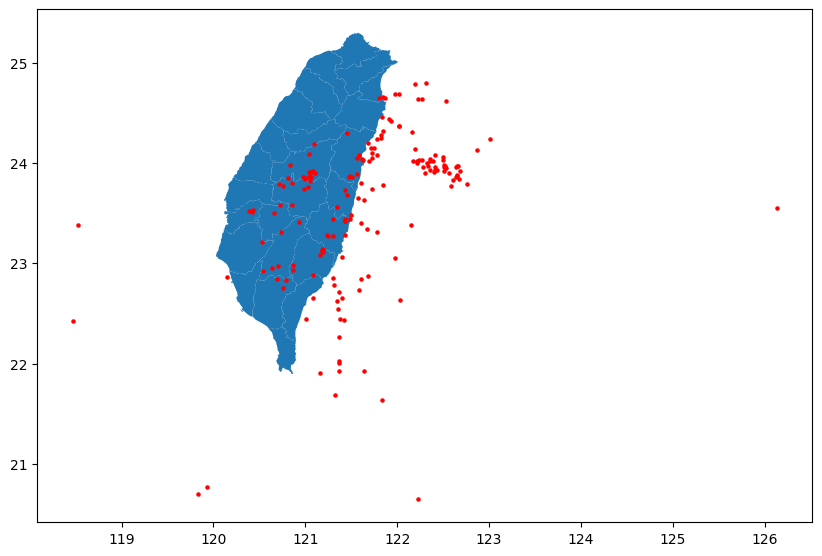

In [11]:
ax = area.plot(figsize=(10, 10))

ax.scatter(target['經度'], target['緯度'], s=5, color='red')

In [12]:
# 取得 花蓮所有測站
alive = json.load(open("../data/各縣市存活測站.json", "r"))
station_loc = np.load("../data/station_locations.pkl", allow_pickle=True)

In [13]:
alive['花蓮縣']

['DCHU',
 'FUDN',
 'JPEI',
 'SPAO',
 'KNKO',
 'YUL1',
 'JSU2',
 'SOFN',
 'SHUL',
 'YENL',
 'BLOW',
 'WARO',
 'JPIN',
 'NDHU',
 'SLIN',
 'HUAP',
 'SCHN',
 'HUAL',
 'SICH',
 'FONB',
 'CHUN',
 'JULI',
 'DNFU',
 'FLNM',
 'TUNM']

In [14]:
# 計算每日累積能量
station_loc[station_loc['name'].isin(alive['花蓮縣'])]

,name,X,Y,U,first_epoch,last_epoch
60,DCHU,278717.043622,2.567917e+06,251.19733,2006-03-29 11:59:00,2023-12-31 11:59:00
64,FUDN,283694.221955,2.572087e+06,267.70168,2011-03-08 11:59:00,2023-12-31 11:59:00
92,JPEI,287922.438090,2.603200e+06,151.53841,2002-01-22 11:59:00,2023-12-31 11:59:00
104,SPAO,299253.357306,2.677814e+06,984.40406,2004-04-07 11:59:00,2023-12-31 11:59:00
111,KNKO,301663.362385,2.596665e+06,43.16126,2002-04-21 11:59:00,2023-12-31 11:59:00
116,YUL1,280702.090047,2.579903e+06,197.58313,2010-12-19 11:59:00,2023-12-31 11:59:00
147,JSU2,293281.006115,2.598869e+06,121.23107,2021-01-25 11:59:00,2023-12-31 11:59:00
173,SOFN,310919.997395,2.640784e+06,58.75613,2005-12-10 11:59:00,2023-12-31 11:59:00
174,SHUL,307347.899295,2.631616e+06,57.97315,2005-06-24 11:59:00,2023-12-31 11:59:00
238,YENL,311279.483993,2.644467e+06,88.27936,2003-01-01 11:59:00,2023-12-31 11:59:00


In [15]:
import math

In [16]:
target_stations = station_loc[station_loc['name'].isin(alive['花蓮縣'])]

In [17]:
# 過濾花蓮的地震事件
inside = False
for i, row in target_stations.iterrows():
    #print(row['X'], row['Y'])
    inside_i = np.hypot(pfile['X'] - row['X'], pfile['Y'] - row['Y']) # 20km
    inside = inside | (inside_i < 20000.0)


In [18]:
hualian = pfile[inside]

In [19]:
from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:3826", "EPSG:3824", always_xy=True)

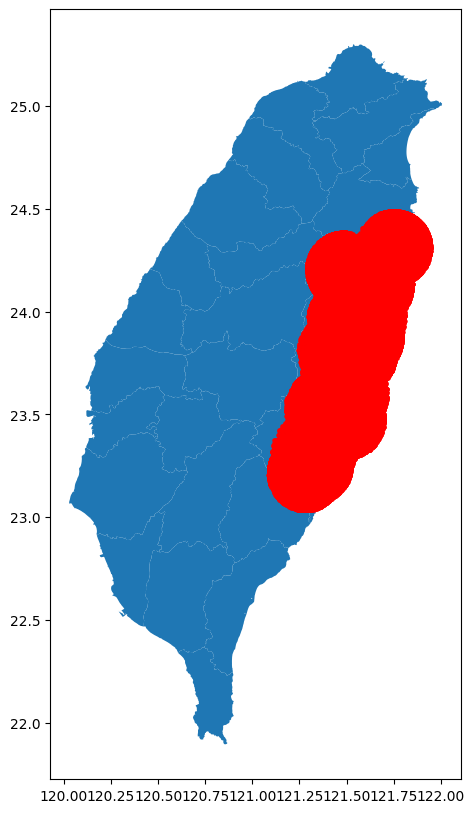

In [20]:
ax = area.plot(figsize=(10, 10))
_long, _lat = transformer.transform(target_stations['X'], target_stations['Y'])
ax.scatter(_long, _lat, color='green')

ax.scatter(hualian['經度'], hualian['緯度'], s=5, color='red')

In [26]:
len(hualian[(hualian['規模'] > 5.5) & (hualian['深度'] < 30.0)])

45

In [27]:
# 花蓮地區 規模 > 5.5 深度 < 30.0 : 45 筆。

In [33]:
# 每日累積能量計算
# logＥ = 11.8+1.5M => E = exp(11.8 + 1.5M)
hualian.loc[:, "能量"] = np.power(10.0, hualian['規模'] * 1.5 + 11.8)

In [34]:
hualian.index = hualian.index.tz_convert("Asia/Taipei")

In [35]:
hualian

,緯度,經度,深度,規模,X,Y,能量
datetime,,,,,,,
1993-01-01 18:49:13.930000+08:00,23.802833,121.665833,19.17,2.93,317846.795048,2.633347e+06,1.566751e+16
1993-01-01 21:58:58.480000+08:00,24.026333,121.680167,29.53,2.88,319188.250001,2.658107e+06,1.318257e+16
1993-01-01 22:35:12.790000+08:00,23.982667,121.710667,28.67,3.70,322315.294891,2.653286e+06,2.238721e+17
1993-01-02 01:59:36.230000+08:00,23.761500,121.575667,1.49,3.17,308677.352430,2.628729e+06,3.589219e+16
1993-01-02 08:44:01.500000+08:00,24.027833,121.644500,32.57,2.95,315559.280925,2.658256e+06,1.678804e+16
...,...,...,...,...,...,...,...
2023-12-24 19:12:52.120000+08:00,24.412000,121.834333,29.37,1.95,334615.956910,2.700907e+06,5.308844e+14
2023-12-24 21:29:19.900000+08:00,23.761667,121.524167,8.85,2.08,303427.816302,2.628727e+06,8.317638e+14
2023-12-25 19:04:24.050000+08:00,23.140667,121.184000,14.52,3.49,268842.680792,2.559872e+06,1.083927e+17


In [143]:
group = hualian.groupby(pd.Grouper(freq='1d', origin="2000-01-01 00:00:00.000000+08:00"))

In [144]:
daily_energy = group['能量'].sum().clip(lower=1e-2) 

In [145]:
daily_mag_scale = (np.log10(daily_energy) - 11.8 ) / 1.5

In [146]:
daily_mag_scale.min()

np.float64(-9.200000000000001)

In [147]:
#logＥ = 11.8+1.5M => E = exp(11.8 + 1.5M)

In [148]:
full_dates = pd.date_range("2000-01-01 00:00:00+08:00", "2023-12-31 23:59:00+08:00")
hualian2 = daily_mag_scale.reindex(full_dates, fill_value=-9.2)

In [122]:
hualian2

2000-01-01 00:00:00+08:00    2.975212
2000-01-02 00:00:00+08:00    3.133236
2000-01-03 00:00:00+08:00    4.410444
2000-01-04 00:00:00+08:00    4.346453
2000-01-05 00:00:00+08:00    3.994433
                               ...   
2023-12-27 00:00:00+08:00   -9.200000
2023-12-28 00:00:00+08:00   -9.200000
2023-12-29 00:00:00+08:00   -9.200000
2023-12-30 00:00:00+08:00   -9.200000
2023-12-31 00:00:00+08:00   -9.200000
Freq: D, Name: 能量, Length: 8766, dtype: float64

In [123]:
hualian2.to_pickle("hualian_daily_acc_energy.pkl")

In [124]:
daily_target_cnt = hualian[(hualian['規模'] > 5.5) & (hualian['深度'] < 30.0)]\
    .groupby(pd.Grouper(freq='1d', origin="1993-01-01 00:00:00.000000+08:00")).size()

daily_target_cnt = daily_target_cnt.reindex(full_dates, fill_value=0)
daily_target_cnt.to_pickle("hualian_target_cnt.pkl")

In [166]:
# 分成 極淺、淺、中層 能量釋放 + 次數 
# 花蓮沒有深層的地震，所以不計
scales = []
counts = []
grouper = pd.Grouper(freq='1d', origin="2000-01-01 00:00:00.000000+08:00")
for d in [ (0, 30), (30, 70), (70, 300)]:
    target_d = hualian[hualian['深度'].between(d[0], d[1], inclusive='left')]
    group = target_d.groupby(by=grouper)
    count_d = group.size().reindex(full_dates).fillna(0)
    scale_d = (( np.log10( group['能量'].sum().clip(lower=1e-2))  - 11.8 ) / 1.5).reindex(full_dates).fillna(-9.2)
    counts.append(count_d)
    scales.append(scale_d)
    

In [167]:
scales[2]

2000-01-01 00:00:00+08:00   -9.2
2000-01-02 00:00:00+08:00   -9.2
2000-01-03 00:00:00+08:00   -9.2
2000-01-04 00:00:00+08:00   -9.2
2000-01-05 00:00:00+08:00   -9.2
                            ... 
2023-12-27 00:00:00+08:00   -9.2
2023-12-28 00:00:00+08:00   -9.2
2023-12-29 00:00:00+08:00   -9.2
2023-12-30 00:00:00+08:00   -9.2
2023-12-31 00:00:00+08:00   -9.2
Freq: D, Name: 能量, Length: 8766, dtype: float64

In [168]:
hualian_statistics = pd.DataFrame({
    "極淺層-能量": scales[0],
    "淺層-能量": scales[1],
    "中層-能量": scales[2],
    "極淺層-次數": counts[0],
    "淺層-次數": counts[1],
    "中層-次數": counts[2],
})

hualian_statistics = hualian_statistics.reindex(full_dates)

In [169]:
hualian_statistics.to_pickle("hualian_daily_statistics.pkl")

In [152]:
## 下面去改 GNSS 的資料

In [153]:
gnss.index = gnss.index.tz_convert("Asia/Taipei").normalize()

In [154]:
gnss2 = gnss[alive['花蓮縣']].copy().reindex(full_dates)

In [155]:
gnss2

station                       DCHU                       FUDN           \
coordinate                      dX       dY       dU       dX       dY   
2000-01-01 00:00:00+08:00      NaN      NaN      NaN      NaN      NaN   
2000-01-02 00:00:00+08:00      NaN      NaN      NaN      NaN      NaN   
2000-01-03 00:00:00+08:00      NaN      NaN      NaN      NaN      NaN   
2000-01-04 00:00:00+08:00      NaN      NaN      NaN      NaN      NaN   
2000-01-05 00:00:00+08:00      NaN      NaN      NaN      NaN      NaN   
...                            ...      ...      ...      ...      ...   
2023-12-27 00:00:00+08:00  0.53492  0.96359 -0.17689  0.41283  0.86322   
2023-12-28 00:00:00+08:00  0.53430  0.96768 -0.17757  0.41304  0.86631   
2023-12-29 00:00:00+08:00  0.53080  0.96482 -0.15862  0.40965  0.86513   
2023-12-30 00:00:00+08:00  0.53441  0.96470 -0.17009  0.41256  0.86563   
2023-12-31 00:00:00+08:00  0.52896  0.96579 -0.17542  0.40828  0.86527   

station                                JPEI                       SPAO  ...  \
coordinate                      dU       dX       dY       dU       dX  ...   
2000-01-01 00:00:00+08:00      NaN      NaN      NaN      NaN      NaN  ...   
2000-01-02 00:00:00+08:00      NaN      NaN      NaN      NaN      NaN  ...   
2000-01-03 00:00:00+08:00      NaN      NaN      NaN      NaN      NaN  ...   
2000-01-04 00:00:00+08:00      NaN      NaN      NaN      NaN      NaN  ...   
2000-01-05 00:00:00+08:00      NaN      NaN      NaN      NaN      NaN  ...   
...                            ...      ...      ...      ...      ...  ...   
2023-12-27 00:00:00+08:00 -0.10009  0.14438 -0.09139  0.11578  0.37152  ...   
2023-12-28 00:00:00+08:00 -0.11408  0.14821 -0.08682  0.12202  0.36943  ...   
2023-12-29 00:00:00+08:00 -0.10730  0.15367 -0.08726  0.11962  0.37118  ...   
2023-12-30 00:00:00+08:00 -0.10608  0.15114 -0.08852  0.11370  0.36889  ...   
2023-12-31 00:00:00+08:00 -0.10618  0.15511 -0.09024  0.11710  0.36735  ...   

station                       JULI     DNFU                       FLNM  \
coordinate                      dU       dX       dY       dU       dX   
2000-01-01 00:00:00+08:00      NaN      NaN      NaN      NaN      NaN   
2000-01-02 00:00:00+08:00      NaN      NaN      NaN      NaN -0.04971   
2000-01-03 00:00:00+08:00      NaN      NaN      NaN      NaN -0.04967   
2000-01-04 00:00:00+08:00      NaN      NaN      NaN      NaN -0.05196   
2000-01-05 00:00:00+08:00      NaN      NaN      NaN      NaN      NaN   
...                            ...      ...      ...      ...      ...   
2023-12-27 00:00:00+08:00  0.84268  0.05385  0.05371  0.11392  0.05705   
2023-12-28 00:00:00+08:00  0.83817  0.05425  0.05985  0.11263  0.05855   
2023-12-29 00:00:00+08:00  0.83827  0.05235  0.05802  0.12307  0.06251   
2023-12-30 00:00:00+08:00  0.84296  0.05529  0.05671  0.12947  0.05753   
2023-12-31 00:00:00+08:00  0.83327  0.06222  0.04964  0.12624  0.06219   

station                                         TUNM                    
coordinate                      dY       dU       dX       dY       dU  
2000-01-01 00:00:00+08:00      NaN      NaN      NaN      NaN      NaN  
2000-01-02 00:00:00+08:00 -0.04494  0.03445      NaN      NaN      NaN  
2000-01-03 00:00:00+08:00 -0.04532  0.04531      NaN      NaN      NaN  
2000-01-04 00:00:00+08:00 -0.04390  0.04451      NaN      NaN      NaN  
2000-01-05 00:00:00+08:00      NaN      NaN      NaN      NaN      NaN  
...                            ...      ...      ...      ...      ...  
2023-12-27 00:00:00+08:00  0.03556 -0.01601  0.09307 -0.12803  0.12554  
2023-12-28 00:00:00+08:00  0.03775 -0.01613  0.09391 -0.12567  0.12241  
2023-12-29 00:00:00+08:00  0.03724 -0.01509  0.09406 -0.12641  0.13085  
2023-12-30 00:00:00+08:00  0.03784 -0.01891  0.09031 -0.12449  0.11596  
2023-12-31 00:00:00+08:00  0.03395 -0.02052  0.09816 -0.12872  0.11113  

[8766 rows x 75 columns]

In [156]:
gnss2 = gnss2.fillna(0.0)

In [157]:
gnss2

station                       DCHU                       FUDN           \
coordinate                      dX       dY       dU       dX       dY   
2000-01-01 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
2000-01-02 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
2000-01-03 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
2000-01-04 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
2000-01-05 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
...                            ...      ...      ...      ...      ...   
2023-12-27 00:00:00+08:00  0.53492  0.96359 -0.17689  0.41283  0.86322   
2023-12-28 00:00:00+08:00  0.53430  0.96768 -0.17757  0.41304  0.86631   
2023-12-29 00:00:00+08:00  0.53080  0.96482 -0.15862  0.40965  0.86513   
2023-12-30 00:00:00+08:00  0.53441  0.96470 -0.17009  0.41256  0.86563   
2023-12-31 00:00:00+08:00  0.52896  0.96579 -0.17542  0.40828  0.86527   

station                                JPEI                       SPAO  ...  \
coordinate                      dU       dX       dY       dU       dX  ...   
2000-01-01 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  ...   
2000-01-02 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  ...   
2000-01-03 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  ...   
2000-01-04 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  ...   
2000-01-05 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  ...   
...                            ...      ...      ...      ...      ...  ...   
2023-12-27 00:00:00+08:00 -0.10009  0.14438 -0.09139  0.11578  0.37152  ...   
2023-12-28 00:00:00+08:00 -0.11408  0.14821 -0.08682  0.12202  0.36943  ...   
2023-12-29 00:00:00+08:00 -0.10730  0.15367 -0.08726  0.11962  0.37118  ...   
2023-12-30 00:00:00+08:00 -0.10608  0.15114 -0.08852  0.11370  0.36889  ...   
2023-12-31 00:00:00+08:00 -0.10618  0.15511 -0.09024  0.11710  0.36735  ...   

station                       JULI     DNFU                       FLNM  \
coordinate                      dU       dX       dY       dU       dX   
2000-01-01 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
2000-01-02 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000 -0.04971   
2000-01-03 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000 -0.04967   
2000-01-04 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000 -0.05196   
2000-01-05 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
...                            ...      ...      ...      ...      ...   
2023-12-27 00:00:00+08:00  0.84268  0.05385  0.05371  0.11392  0.05705   
2023-12-28 00:00:00+08:00  0.83817  0.05425  0.05985  0.11263  0.05855   
2023-12-29 00:00:00+08:00  0.83827  0.05235  0.05802  0.12307  0.06251   
2023-12-30 00:00:00+08:00  0.84296  0.05529  0.05671  0.12947  0.05753   
2023-12-31 00:00:00+08:00  0.83327  0.06222  0.04964  0.12624  0.06219   

station                                         TUNM                    
coordinate                      dY       dU       dX       dY       dU  
2000-01-01 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  
2000-01-02 00:00:00+08:00 -0.04494  0.03445  0.00000  0.00000  0.00000  
2000-01-03 00:00:00+08:00 -0.04532  0.04531  0.00000  0.00000  0.00000  
2000-01-04 00:00:00+08:00 -0.04390  0.04451  0.00000  0.00000  0.00000  
2000-01-05 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  
...                            ...      ...      ...      ...      ...  
2023-12-27 00:00:00+08:00  0.03556 -0.01601  0.09307 -0.12803  0.12554  
2023-12-28 00:00:00+08:00  0.03775 -0.01613  0.09391 -0.12567  0.12241  
2023-12-29 00:00:00+08:00  0.03724 -0.01509  0.09406 -0.12641  0.13085  
2023-12-30 00:00:00+08:00  0.03784 -0.01891  0.09031 -0.12449  0.11596  
2023-12-31 00:00:00+08:00  0.03395 -0.02052  0.09816 -0.12872  0.11113  

[8766 rows x 75 columns]

In [158]:
# 存檔 
gnss2.to_pickle("hualian_daily_gnss_dXdYdU.pkl")